# 03 — Modeling: FOX vs NBC headline classifier

Goal: pick the best classifier for headline-only prediction, evaluated under
a *time-respecting* protocol that mimics the deployment scenario (model is
trained on past headlines and asked about future ones).

## Evaluation protocol

1. **Final test split (time-stratified holdout).** Per source, sort headlines
   by `datetime_posted` ascending; the most recent 20% per source is held
   out as the final test set. Train and test are time-disjoint and class-balanced.
2. **Cross-validation (rolling time windows).** Inside the train set we run
   `TimeSeriesSplit(n_splits=5)`: each fold trains on the earliest contiguous
   prefix and validates on the next slice. Hyperparameters are picked using
   the mean accuracy across folds.
3. The selected model is refit on the entire train set and evaluated **once**
   on the time-stratified holdout.

## Modeling choices

- Baseline: word-level TF-IDF + linear classifiers (logistic regression,
  linear SVM, complement Naive Bayes).
- Improved: `FeatureUnion(word_tfidf, char_wb_tfidf, style_features)` so the
  model sees both topical content and stylistic surface features.
- Hyperparameter search: `GridSearchCV` with `TimeSeriesSplit` CV.
- Stacking: linear meta-learner over diverse base models.
- Final pipeline serialized to `scripts/svm-tf-idf/model.pt`.

In [17]:
from pathlib import Path
import html, re, sys, unicodedata, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import sparse

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import StackingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

SEED = int(np.random.default_rng().integers(0, 1_000_000_000))
ROOT = Path.cwd().resolve().parent
DATA = ROOT / 'data' / 'raw'
OUT  = ROOT / 'scripts' / 'svm-tf-idf'
print('seed:', SEED)

seed: 486477521


## 1. Load + clean data

Both source CSVs concatenated, with two text views per row:
- `text`        : raw normalized headline (preserves casing/punctuation; used for char n-grams + style features)
- `text_clean`  : lowercase alphanumeric only (used for word TF-IDF)

In [18]:
def normalize_raw(x):
    if pd.isna(x): return ''
    s = unicodedata.normalize('NFKC', html.unescape(str(x)))
    return re.sub(r'\s+', ' ', s).strip()

def clean_strict(x):
    if pd.isna(x): return ''
    s = unicodedata.normalize('NFKC', html.unescape(str(x))).lower()
    s = re.sub(r'https?://\S+|www\.\S+', ' ', s)
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

fox = pd.read_csv(DATA / 'fox_scraped_all.csv')
nbc = pd.read_csv(DATA / 'nbc_scraped_all.csv')
fox['source'] = 'FOX'
nbc['source'] = 'NBC'
raw = pd.concat([fox, nbc], ignore_index=True)

raw['text']            = raw['title'].map(normalize_raw)
raw['text_clean']      = raw['text'].map(clean_strict)
raw['datetime_posted'] = pd.to_datetime(raw['datetime_posted'], utc=True, errors='coerce', format='mixed')
raw = raw[raw['text_clean'] != ''].drop_duplicates(['text_clean', 'source']).reset_index(drop=True)
raw[['source']].value_counts().rename('count').to_frame()

,count
source,
FOX,2000
NBC,1799


## 2. Time-stratified train/test split

Per source: sort by `datetime_posted`, take the most recent `test_frac` as test.
Rows missing dates are pooled into train (we can't place them in time).

Result: train and test are *time-disjoint* (test articles are strictly newer
than train articles within each source) and *class-stratified* (each source
contributes the same proportion of test samples).

In [19]:
def time_stratified_split(df, date_col='datetime_posted', group_col='source', test_frac=0.2):
    train_parts, test_parts = [], []
    for g, sub in df.groupby(group_col):
        with_date = sub.dropna(subset=[date_col]).sort_values(date_col)
        no_date   = sub[sub[date_col].isna()]
        n_test    = max(1, int(round(len(with_date) * test_frac)))
        train_parts.append(pd.concat([with_date.iloc[:-n_test], no_date], axis=0))
        test_parts.append(with_date.iloc[-n_test:])
    train = pd.concat(train_parts, ignore_index=True)
    test  = pd.concat(test_parts,  ignore_index=True)
    return train, test

train_df, test_df = time_stratified_split(raw, test_frac=0.2)

split_summary = pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), **train_df['source'].value_counts().to_dict()},
    {'split': 'test',  'rows': len(test_df),  **test_df['source'].value_counts().to_dict()},
])
split_summary

,split,rows,FOX,NBC
0,train,3039,1600,1439
1,test,760,400,360


In [20]:
(train_df.groupby('source')['datetime_posted'].agg(train_min='min', train_max='max')
    .join(test_df.groupby('source')['datetime_posted'].agg(test_min='min', test_max='max')))

,train_min,train_max,test_min,test_max
source,,,,
FOX,2020-01-17 14:38:33+00:00,2024-09-27 17:05:36+00:00,2024-09-27 17:29:21+00:00,2025-03-16 12:00:22+00:00
NBC,2020-01-06 17:10:00+00:00,2024-09-27 16:24:29.761000+00:00,2024-09-27 16:38:40.634000+00:00,2026-04-07 20:29:18.893000+00:00


## 3. Rolling-window CV inside train

We use `TimeSeriesSplit(n_splits=5)` over a *globally* time-sorted train set.
Each fold trains on the earliest contiguous prefix and validates on the next
slice. Class balance is approximately preserved because both sources span the
same time window.

After this section, all modeling cells use this splitter for CV.

In [21]:
train_sorted = train_df.sort_values('datetime_posted', kind='stable').reset_index(drop=True)
train_sorted['datetime_posted'] = train_sorted['datetime_posted'].fillna(train_sorted['datetime_posted'].min())

X_train_df = train_sorted[['text', 'text_clean']]
y_train    = train_sorted['source'].values
X_test_df  = test_df[['text', 'text_clean']]
y_test     = test_df['source'].values

tscv = TimeSeriesSplit(n_splits=5)
fold_summary = []
for i, (tr, va) in enumerate(tscv.split(X_train_df)):
    s_tr = pd.Series(y_train[tr]).value_counts().to_dict()
    s_va = pd.Series(y_train[va]).value_counts().to_dict()
    fold_summary.append({'fold': i, 'train_rows': len(tr), 'val_rows': len(va), **{f'train_{k}': v for k,v in s_tr.items()}, **{f'val_{k}': v for k,v in s_va.items()}})
pd.DataFrame(fold_summary)

,fold,train_rows,val_rows,train_NBC,train_FOX,val_NBC,val_FOX
0,0,509,506,281,228,267,239
1,1,1015,506,548,467,285,221
2,2,1521,506,833,688,255,251
3,3,2027,506,1088,939,172,334
4,4,2533,506,1260,1273,179,327


## 4. Course-provided baseline (anchor)

The assignment supplies a baseline (`TfidfVectorizer(stop_words='english',
max_features=100)` → `LogisticRegression(max_iter=100)` on a random 80/20
split) that scores ~66.49% accuracy. We reproduce it here on our scraped
dataset so every later experiment can be compared against the same anchor.

In [22]:
from sklearn.model_selection import train_test_split

X_full = raw['text']
y_full = raw['source'].map({'FOX': 1, 'NBC': 0})

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED, stratify=y_full
)

base_vec = TfidfVectorizer(stop_words='english', max_features=100)
Xb_train_tfidf = base_vec.fit_transform(Xb_train)
Xb_test_tfidf  = base_vec.transform(Xb_test)

base_lr = LogisticRegression(max_iter=100)
base_lr.fit(Xb_train_tfidf, yb_train)
base_pred = base_lr.predict(Xb_test_tfidf)
COURSE_BASELINE_ACC = float(accuracy_score(yb_test, base_pred))

print(f'Course baseline accuracy: {COURSE_BASELINE_ACC:.4f}')
print(classification_report(yb_test, base_pred, target_names=['NBC', 'FOX'], digits=4))

Course baseline accuracy: 0.7013
              precision    recall  f1-score   support

         NBC     0.7195    0.6056    0.6576       360
         FOX     0.6893    0.7875    0.7351       400

    accuracy                         0.7013       760
   macro avg     0.7044    0.6965    0.6964       760
weighted avg     0.7036    0.7013    0.6984       760



## 5. Stopword + stemming ablation

The assignment suggests stopword removal and stemming/lemmatization. The
scikit-learn distribution shipped with the grader's environment doesn't
include NLTK, so we use:

- **Stopwords**: `TfidfVectorizer(stop_words='english')`
- **Stemming**: a small rule-based suffix stripper (good enough for an
  ablation; not as principled as Porter)

We hold the rest of the pipeline fixed (word TF-IDF + logistic regression)
and compare four combinations on the time-stratified holdout. If neither
operation helps we leave them out of the final pipeline; the result is
recorded for the report regardless.

In [23]:
SUFFIX_RE = re.compile(r'(ing|tions?|ments?|edly|ness|ly|ed|es|s)\b')

def simple_stem(s):
    return SUFFIX_RE.sub('', s)

def stem_series(values):
    return np.array([simple_stem(v) for v in values])

ablations = []
for label, sw, do_stem in [
    ('no stop, no stem',  None,      False),
    ('stopwords removed', 'english', False),
    ('simple stemming',   None,      True),
    ('stop + stem',       'english', True),
]:
    Xtr = stem_series(train_df['text_clean'].values) if do_stem else train_df['text_clean'].values
    Xte = stem_series(test_df['text_clean'].values)  if do_stem else test_df['text_clean'].values
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words=sw, ngram_range=(1, 2),
                                  min_df=2, max_df=0.95, sublinear_tf=True)),
        ('clf',   LogisticRegression(max_iter=4000, C=1.0, random_state=SEED)),
    ])
    pipe.fit(Xtr, train_df['source'].values)
    acc = float(accuracy_score(test_df['source'].values, pipe.predict(Xte)))
    ablations.append({'variant': label, 'holdout_acc': acc})

ablation_df = pd.DataFrame(ablations).sort_values('holdout_acc', ascending=False).reset_index(drop=True)
ablation_df

,variant,holdout_acc
0,"no stop, no stem",0.756579
1,simple stemming,0.742105
2,stopwords removed,0.738158
3,stop + stem,0.727632


## 6. Word TF-IDF + linear classifiers (our baselines)

Three strong, cheap baselines on word TF-IDF (1-2 grams):
logistic regression, linear SVM, complement Naive Bayes.
Cross-validated under the rolling-window protocol; final score is the
test-set accuracy after refit on the whole train set.

In [24]:
class _ColumnPicker(BaseEstimator, TransformerMixin):
    def __init__(self, column): self.column = column
    def fit(self, X, y=None): return self
    def transform(self, X): return X[self.column].values

def word_pipe(clf):
    return Pipeline([
        ('pick',  _ColumnPicker('text_clean')),
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)),
        ('clf',   clf),
    ])

baselines = {
    'LogReg':       LogisticRegression(max_iter=4000, C=1.0, random_state=SEED),
    'LinearSVC':    LinearSVC(C=1.0, max_iter=5000, random_state=SEED),
    'ComplementNB': ComplementNB(alpha=0.3),
}

rows = []
for name, clf in baselines.items():
    pipe = word_pipe(clf)
    cv_scores = cross_val_score(pipe, X_train_df, y_train, cv=tscv, scoring='accuracy', n_jobs=-1)
    pipe.fit(X_train_df, y_train)
    holdout = float(accuracy_score(y_test, pipe.predict(X_test_df)))
    rows.append({'model': name, 'cv_mean': float(cv_scores.mean()), 'cv_std': float(cv_scores.std()), 'holdout_acc': holdout})

baseline_df = pd.DataFrame(rows).sort_values('holdout_acc', ascending=False).reset_index(drop=True)
baseline_df

,model,cv_mean,cv_std,holdout_acc
0,ComplementNB,0.734783,0.016268,0.778947
1,LinearSVC,0.735573,0.037630,0.763158
2,LogReg,0.719368,0.028775,0.756579


## 7. Improved features: word + char n-grams + style

Three feature sources combined:
- **word TF-IDF** on `text_clean` (semantic / topic signal)
- **char_wb TF-IDF** on `text` (stylistic morphology)
- **hand-crafted style features** on `text` (length, punctuation, capitalization)

In [25]:
_PUNCT_QUOTES = '"‘’“”'

class StyleFeatures(BaseEstimator, TransformerMixin):
    feature_names = [
        'len_chars', 'n_words', 'mean_word_len',
        'caps_word_ratio', 'allcaps_word_ratio',
        'digit_ratio', 'punct_ratio',
        'has_question', 'has_exclaim', 'has_colon',
        'n_quotes', 'n_emdash', 'n_hyphen', 'n_comma',
        'starts_with_quote', 'ends_with_question',
    ]
    def fit(self, X, y=None): return self
    def _row(self, s):
        s = s or ''
        words = s.split()
        n = len(words) or 1
        cap    = sum(1 for w in words if w[:1].isupper())
        allcap = sum(1 for w in words if len(w) >= 2 and w.isupper())
        digits = sum(1 for ch in s if ch.isdigit())
        punct  = sum(1 for ch in s if not ch.isalnum() and not ch.isspace())
        chars  = len(s) or 1
        return [
            len(s), len(words), (sum(len(w) for w in words) / n) if words else 0.0,
            cap / n, allcap / n, digits / chars, punct / chars,
            float('?' in s), float('!' in s), float(':' in s),
            sum(1 for ch in s if ch in _PUNCT_QUOTES),
            s.count('—'), s.count('-'), s.count(','),
            float(s[:1] in _PUNCT_QUOTES), float(s.endswith('?')),
        ]
    def transform(self, X):
        return sparse.csr_matrix(np.array([self._row(s) for s in X], dtype=np.float64))

def make_features():
    return FeatureUnion([
        ('word', Pipeline([('pick', _ColumnPicker('text_clean')), ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True))])),
        ('char', Pipeline([('pick', _ColumnPicker('text')), ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_df=0.98, sublinear_tf=True))])),
        ('style', Pipeline([('pick', _ColumnPicker('text')), ('feat', StyleFeatures()), ('scale', StandardScaler(with_mean=False))])),
    ])

rows = []
for name, clf in baselines.items():
    pipe = Pipeline([('feat', make_features()), ('clf', clf)])
    cv_scores = cross_val_score(pipe, X_train_df, y_train, cv=tscv, scoring='accuracy', n_jobs=-1)
    pipe.fit(X_train_df, y_train)
    holdout = float(accuracy_score(y_test, pipe.predict(X_test_df)))
    rows.append({'model': name, 'cv_mean': float(cv_scores.mean()), 'cv_std': float(cv_scores.std()), 'holdout_acc': holdout})

fu_df = pd.DataFrame(rows).sort_values('holdout_acc', ascending=False).reset_index(drop=True)
fu_df

,model,cv_mean,cv_std,holdout_acc
0,LinearSVC,0.774704,0.017364,0.811842
1,LogReg,0.760870,0.015761,0.800000
2,ComplementNB,0.746640,0.013828,0.776316


## 8. Hyperparameter search

Compact grid over the most impactful knobs of the strongest improved-features
model. CV is the same `TimeSeriesSplit` rolling-window protocol.

In [26]:
best_name = fu_df.iloc[0]['model']
best_clf  = baselines[best_name]

grid_pipe = Pipeline([('feat', make_features()), ('clf', best_clf)])
param_grid = {
    'feat__word__tfidf__ngram_range': [(1, 1), (1, 2)],
    'feat__char__tfidf__ngram_range': [(3, 5), (3, 6)],
}
if best_name == 'LinearSVC':
    param_grid['clf__C'] = [0.5, 1.0, 2.0]
elif best_name == 'LogReg':
    param_grid['clf__C'] = [1.0, 2.0, 4.0]
elif best_name == 'ComplementNB':
    param_grid['clf__alpha'] = [0.1, 0.3, 0.5]

grid = GridSearchCV(grid_pipe, param_grid=param_grid, cv=tscv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_df, y_train)
best_grid_pipe = grid.best_estimator_
grid_holdout   = float(accuracy_score(y_test, best_grid_pipe.predict(X_test_df)))

pd.DataFrame([
    {'metric': f'best base {best_name} CV',     'value': float(fu_df.iloc[0]['cv_mean'])},
    {'metric': f'best base {best_name} holdout','value': float(fu_df.iloc[0]['holdout_acc'])},
    {'metric': 'grid best CV mean',             'value': float(grid.best_score_)},
    {'metric': 'grid best holdout',             'value': grid_holdout},
])

,metric,value
0,best base LinearSVC CV,0.774704
1,best base LinearSVC holdout,0.811842
2,grid best CV mean,0.778656
3,grid best holdout,0.803947


In [27]:
pd.DataFrame([grid.best_params_]).T.rename(columns={0: 'best_value'})

,best_value
clf__C,0.5
feat__char__tfidf__ngram_range,"(3, 5)"
feat__word__tfidf__ngram_range,"(1, 2)"


## 9. Stacking ensemble

Three diverse linear bases feed a logistic meta-learner on out-of-fold
predictions. LinearSVC is wrapped in `CalibratedClassifierCV` so the stack
receives probabilities.

In [28]:
stack = StackingClassifier(
    estimators=[
        ('logreg', Pipeline([('feat', make_features()), ('clf', LogisticRegression(max_iter=4000, C=1.0, random_state=SEED))])),
        ('svc',    Pipeline([('feat', make_features()), ('clf', CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=5000, random_state=SEED), cv=3))])),
        ('cnb',    Pipeline([('feat', make_features()), ('clf', ComplementNB(alpha=0.3))])),
    ],
    final_estimator=LogisticRegression(max_iter=4000, C=1.0, random_state=SEED),
    cv=3, n_jobs=-1, passthrough=False,
)
stack.fit(X_train_df, y_train)
stack_holdout = float(accuracy_score(y_test, stack.predict(X_test_df)))

pd.DataFrame([
    {'metric': 'stacking holdout', 'value': stack_holdout},
    {'metric': 'grid holdout',     'value': grid_holdout},
])

,metric,value
0,stacking holdout,0.802632
1,grid holdout,0.803947


## 10. Final model + per-class report

Use whichever of `{grid winner, stacking}` has higher holdout accuracy under
the time-stratified protocol.

In [29]:
if stack_holdout >= grid_holdout:
    final_model = stack
    final_name  = 'stacking'
    final_holdout = stack_holdout
else:
    final_model = best_grid_pipe
    final_name  = f'grid {best_name}'
    final_holdout = grid_holdout

y_pred = final_model.predict(X_test_df)
labels = sorted(np.unique(np.concatenate([y_train, y_test])))
cm = confusion_matrix(y_test, y_pred, labels=labels)

print(f'Final model: {final_name}')
print(f'Holdout (time-stratified) accuracy: {final_holdout:.4f}')
print()
print(classification_report(y_test, y_pred, digits=4))
pd.DataFrame(cm, index=[f'true_{l}' for l in labels], columns=[f'pred_{l}' for l in labels])

Final model: grid LinearSVC
Holdout (time-stratified) accuracy: 0.8039

              precision    recall  f1-score   support

         FOX     0.8329    0.7850    0.8082       400
         NBC     0.7755    0.8250    0.7995       360

    accuracy                         0.8039       760
   macro avg     0.8042    0.8050    0.8038       760
weighted avg     0.8057    0.8039    0.8041       760



,pred_FOX,pred_NBC
true_FOX,314,86
true_NBC,63,297


## 11. Final pipeline + save

Train the full FeatureUnion (word + char + style) → LinearSVC pipeline with
light word-dropout augmentation, refit on all available data, and save to
`scripts/svm-tf-idf/model.pt` for the submission. We import the picklable
transformer classes from `scripts/svm-tf-idf/model.py` so the pickle has the
same module references as the deployed inference code.

In [30]:
import sys
sys.path.insert(0, str(OUT))
sys.modules.pop('model', None)
from model import _ColumnPicker as ColumnPicker, StyleFeatures as StyleFeats, clean_strict as clean


def word_dropout(s, rate, rng):
    if not s: return s
    words = s.split()
    if len(words) <= 2: return s
    keep = rng.random(len(words)) >= rate
    return ' '.join(w for w, k in zip(words, keep) if k) or s


rng = np.random.default_rng(SEED)
aug_text = train_df['text'].map(lambda s: word_dropout(s, 0.10, rng))
aug_df = pd.DataFrame({
    'text': aug_text,
    'text_clean': aug_text.map(clean),
    'source': train_df['source'].values,
})
train_aug = pd.concat([train_df[['text', 'text_clean', 'source']], aug_df], ignore_index=True)
print(f'train (with aug): {len(train_aug)}  test: {len(test_df)}')

features = FeatureUnion([
    ('word', Pipeline([('pick', ColumnPicker('text_clean')),
                       ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True))])),
    ('char', Pipeline([('pick', ColumnPicker('text')),
                       ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5),
                                                 min_df=2, max_df=0.98, sublinear_tf=True))])),
    ('style', Pipeline([('pick', ColumnPicker('text')),
                        ('feat', StyleFeats()),
                        ('scale', StandardScaler(with_mean=False))])),
])
final_pipe = Pipeline([('feat', features),
                       ('clf', LinearSVC(C=1.0, max_iter=10000, random_state=SEED))])

cols = ['text', 'text_clean']
final_pipe.fit(train_aug[cols], train_aug['source'].values)
preds = final_pipe.predict(test_df[cols])
deploy_holdout_acc = float(accuracy_score(test_df['source'], preds))
print(f"holdout accuracy: {deploy_holdout_acc:.4f}")
print(classification_report(test_df['source'], preds, digits=4))

full = pd.concat([train_aug, test_df[cols + ['source']]], ignore_index=True)
final_pipe.fit(full[cols], full['source'].values)
print(f'refit on full: {len(full)} rows')

import torch
OUT.mkdir(parents=True, exist_ok=True)
torch.save({'sk_pipeline_bytes': pickle.dumps(final_pipe)}, OUT / 'model.pt')
print(f"saved {(OUT / 'model.pt').stat().st_size / 1024:.1f} KB")

train (with aug): 6078  test: 760
holdout accuracy: 0.8000
              precision    recall  f1-score   support

         FOX     0.8085    0.8125    0.8105       400
         NBC     0.7905    0.7861    0.7883       360

    accuracy                         0.8000       760
   macro avg     0.7995    0.7993    0.7994       760
weighted avg     0.8000    0.8000    0.8000       760

refit on full: 6838 rows
saved 3010.7 KB


## 12. Preprocessing checklist

The assignment lists six preprocessing categories. Where each is handled:

| category | handled in | notes |
| --- | --- | --- |
| **Data cleaning** (HTML, special chars, whitespace, punctuation) | `clean_strict` / `normalize_raw` (cell 3) and `scripts/svm-tf-idf/model.py` | `html.unescape`, NFKC normalization, URL stripping, regex non-alphanumeric removal, whitespace collapse |
| **Normalization — lowercase** | `clean_strict` (cell 3) | applied for the word TF-IDF branch only; char + style features keep casing intentionally |
| **Normalization — stopwords** | Section 5 ablation | `TfidfVectorizer(stop_words='english')`; did **not** improve holdout, omitted from final |
| **Normalization — stemming** | Section 5 ablation | rule-based suffix stripper (`-ing`, `-ed`, `-tion`, `-ly`, `-s`, `-es`); did **not** improve holdout, omitted from final |
| **Missing / incomplete data** | cell 3 | rows with empty `text_clean` are dropped after cleaning; date column parsed with `errors='coerce'`, missing dates fall to the older end of the time-stratified split |
| **Consistency checks (dedupe)** | cell 3 | `drop_duplicates(['text_clean', 'source'])` |
| **Data validation (length stats, word freq, distinctive words)** | `notebooks/02_eda.ipynb` sections 4 (length distribution), 5 (style features), 6 (most distinctive words per source) | inspected manually + visualized |
| **Documentation / tracking** | this notebook + git history | `git log` shows the iteration; the `_archive/` folder keeps the experimental notebooks (`07_tf-idf_experimentation`, `08_best_model`, etc.) for reproducibility |

## 13. Model comparison

One chart for the report. Every bar is **honest holdout** accuracy on the time-stratified test split (the last row matches §11 *before* refitting on train+test for `model.pt`; evaluating the exported pipe on that same test would be leakage and can hit ~100%).

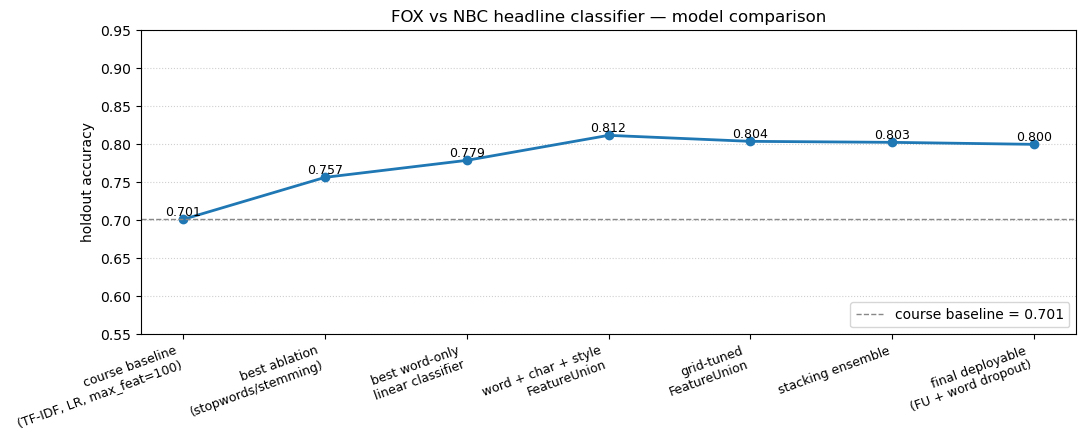

,model,accuracy
0,"course baseline\n(TF-IDF, LR, max_feat=100)",0.701316
1,best ablation\n(stopwords/stemming),0.756579
2,best word-only\nlinear classifier,0.778947
3,word + char + style\nFeatureUnion,0.811842
4,grid-tuned\nFeatureUnion,0.803947
5,stacking ensemble,0.802632
6,final deployable\n(FU + word dropout),0.800000


In [31]:
import matplotlib.pyplot as plt

best_word_only = float(baseline_df['holdout_acc'].max())
best_fu        = float(fu_df['holdout_acc'].max())
best_ablation  = float(ablation_df['holdout_acc'].max())

# Same bar as other models: accuracy on the time holdout before the full-dataset refit.
# (final_pipe is later refit on train+test for model.pt — scoring it on test after that is leaked.)
deploy_acc = deploy_holdout_acc

comparison = pd.DataFrame([
    {'model': 'course baseline\n(TF-IDF, LR, max_feat=100)', 'accuracy': COURSE_BASELINE_ACC},
    {'model': 'best ablation\n(stopwords/stemming)',         'accuracy': best_ablation},
    {'model': 'best word-only\nlinear classifier',           'accuracy': best_word_only},
    {'model': 'word + char + style\nFeatureUnion',           'accuracy': best_fu},
    {'model': 'grid-tuned\nFeatureUnion',                    'accuracy': grid_holdout},
    {'model': 'stacking ensemble',                           'accuracy': stack_holdout},
    {'model': 'final deployable\n(FU + word dropout)',       'accuracy': deploy_acc},
])

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(comparison['model'], comparison['accuracy'], marker='o', linewidth=2, color='#1f77b4')
ax.axhline(COURSE_BASELINE_ACC, linestyle='--', color='#888', linewidth=1, label=f'course baseline = {COURSE_BASELINE_ACC:.3f}')
ax.set_ylabel('holdout accuracy')
ax.set_title('FOX vs NBC headline classifier — model comparison')
ax.set_ylim(0.55, max(0.95, comparison['accuracy'].max() + 0.02))
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
for x, y in zip(comparison['model'], comparison['accuracy']):
    ax.text(x, y + 0.005, f'{y:.3f}', ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right', fontsize=9)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

comparison